<a href="https://colab.research.google.com/github/Caduescanti/CNN_-em-um-problema-de-classifica-ao-binaria-ou-multiplas-classes-trabalhoFinal.ipynb/blob/main/CNN__em_um_problema_de_classifica%C3%A7ao_binaria_ou_multiplas_classes_trabalhoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aplicação de Redes Neurais Convolucionais (CNN) em um problema de classificação binária ou com múltiplas classes.

In [ ]:
!pip install tensorflow
!pip install keras

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow import keras
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import random
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


O dataset escolhido foi o [Classificação de pacientes com pneumonia utilizando imagens de raio-x.](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Diretórios do dataset
train_dir = '/content/drive/MyDrive/Faculdade/IA/Atividades/ListasComputacionais/chest_xray/train'
val_dir = '/content/drive/MyDrive/Faculdade/IA/Atividades/ListasComputacionais/chest_xray/val'
test_dir = '/content/drive/MyDrive/Faculdade/IA/Atividades/ListasComputacionais/chest_xray/test'

In [ ]:
PNEUMONIA = os.listdir("/content/drive/MyDrive/Faculdade/IA/Atividades/ListasComputacionais/chest_xray/train/PNEUMONIA")
NORMAL = os.listdir("/content/drive/MyDrive/Faculdade/IA/Atividades/ListasComputacionais/chest_xray/train/NORMAL")
len(PNEUMONIA) + len(NORMAL)

5216

## Exemplos das imagens para cada diretório

In [ ]:
def plot_images(dirr, folder):
    plt.figure(figsize=(20,10))
    for index, img in enumerate(random.sample(dirr, 6)):
        plt.subplot(230 + index + 1)
        img_rgb = cv2.cvtColor(cv2.imread(os.path.join(train_dir, folder, img)), cv2.COLOR_BGR2GRAY)
        plt.imshow(img_rgb, cmap='gray')

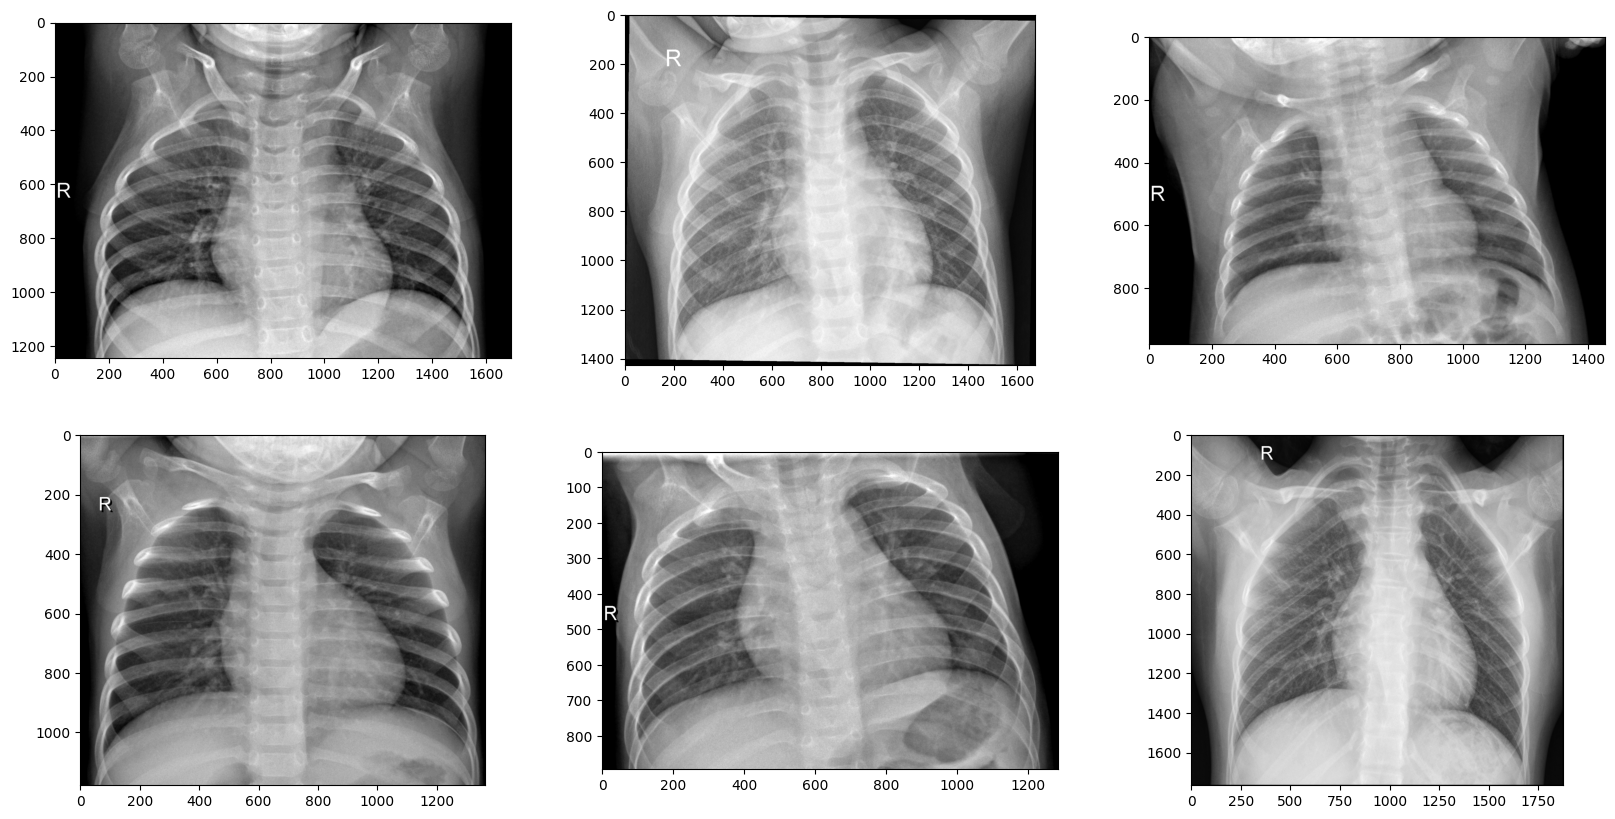

In [ ]:
plot_images(NORMAL, "NORMAL")

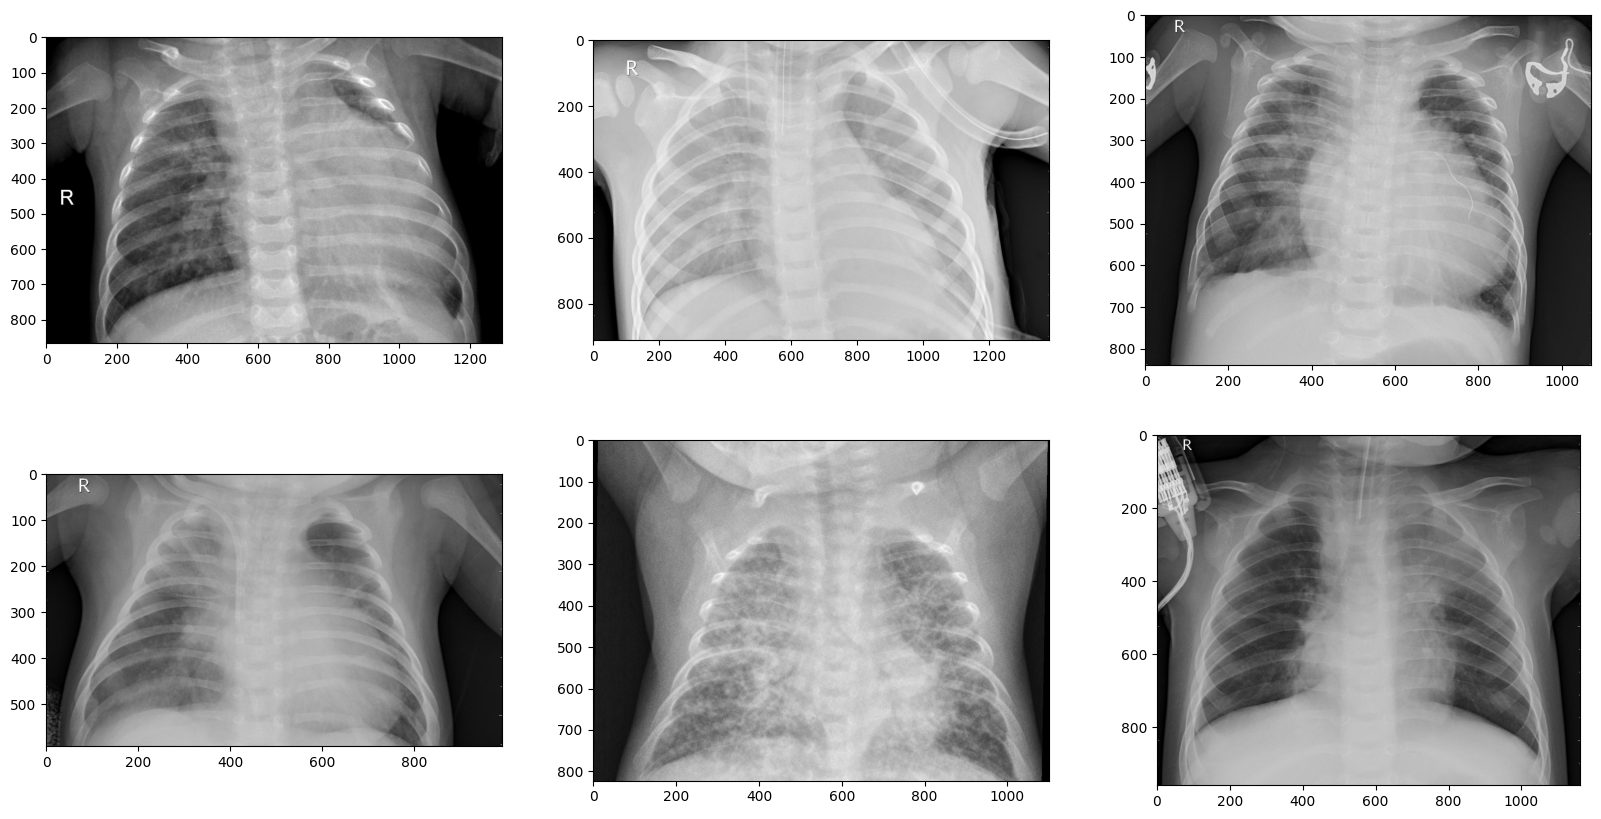

In [ ]:
plot_images(PNEUMONIA, "PNEUMONIA")

Quantidade de Imagens para cada 'classe'

In [ ]:
len(PNEUMONIA), len(NORMAL)

(3875, 1341)

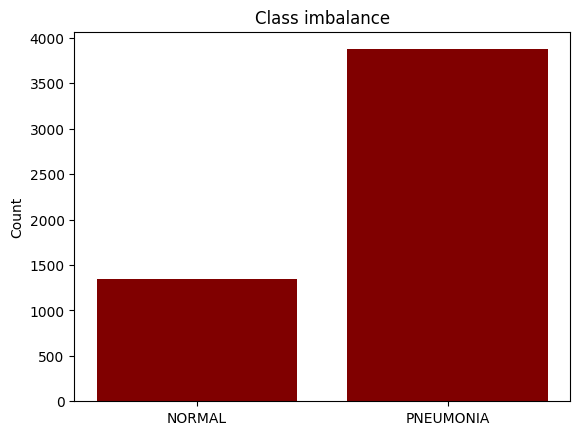

In [ ]:
counts = {"NORMAL": len(NORMAL), "PNEUMONIA": len(PNEUMONIA)}

plt.bar(list(counts.keys()), list(counts.values()), color ='maroon')

plt.xlabel('')
plt.ylabel('Count')
plt.title('Class imbalance')

plt.show()

In [ ]:
bias = np.log([len(PNEUMONIA)/len(NORMAL)])
bias

array([1.06113006])

Atribuiremos novos pesos para contrabalançar as classes de desequilíbrio. Eu estava pensando em Oversampling ou Downsampling, mas decidi não alterar o próprio conjunto de dados.

In [ ]:
class_0 = 5216/(2*1342)
class_1 = 5216/(2*3876)

class_weights = {0: class_0, 1: class_1}

print('Class 0: {:.2f}'.format(class_0))
print('Class 1: {:.2f}'.format(class_1))

Class 0: 1.94
Class 1: 0.67


## Construindo CNN

In [ ]:
batch_size = 32
img_height = 150
img_width = 150

train_data = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  seed=42,
  image_size=(img_height, img_width),
  batch_size=batch_size)

test_data = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  seed=42,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_data = tf.keras.utils.image_dataset_from_directory(
  val_dir,
  seed=42,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Found 16 files belonging to 2 classes.


In [ ]:
train_data.class_names

['NORMAL', 'PNEUMONIA']

## Treinando o modelo

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Rescaling, BatchNormalization
from tensorflow.keras.regularizers import l2

cnn_model = Sequential(
        [

            Rescaling(1/255),

            Conv2D(32, 3, activation='relu', kernel_regularizer=l2(0.0001)),
            Conv2D(32, 3, activation='relu'),
            BatchNormalization(),
            MaxPooling2D(),
            Dropout(0.2),

            Conv2D(64, 3, activation='relu', kernel_regularizer=l2(0.0001)),
            MaxPooling2D(),
            Dropout(0.2),

            Conv2D(128, 3, activation='relu', kernel_regularizer=l2(0.0001)),
            MaxPooling2D(),
            Dropout(0.2),

            Conv2D(256, 3, activation='relu', kernel_regularizer=l2(0.0001)),
            MaxPooling2D(),
            Dropout(0.2),

            Flatten(),
            Dense(units=64, activation='relu'),
            Dropout(0.5),
            Dense(units=1, activation='sigmoid')

        ]
        )

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

early_stopping_cb = EarlyStopping(monitor='val_loss', min_delta=0.0001, verbose=1, patience=5,
                                      restore_best_weights=True)

cnn_model.compile(loss='binary_crossentropy',
                optimizer=Adam(learning_rate=0.0001, beta_1=0.92, beta_2=0.999),
                metrics=['accuracy',tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')])

cnn_model_hist = cnn_model.fit(train_data,
                        epochs=5,
                        class_weight=class_weights,
                        validation_data=test_data, callbacks=[early_stopping_cb])

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 744s 4s/step - accuracy: 0.9450 - loss: 0.1748 - precision: 0.9830 - recall: 0.9413 - val_accuracy: 0.7468 - val_loss: 0.5190 - val_precision: 0.7148 - val_recall: 0.9897
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 743s 4s/step - accuracy: 0.9515 - loss: 0.1672 - precision: 0.9846 - recall: 0.9487 - val_accuracy: 0.8141 - val_loss: 0.4408 - val_precision: 0.7785 - val_recall: 0.9821
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 729s 4s/step - accuracy: 0.9571 - loss: 0.1457 - precision: 0.9886 - recall: 0.9525 - val_accuracy: 0.8750 - val_loss: 0.3509 - val_precision: 0.8578 - val_recall: 0.9590
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 757s 5s/step - accuracy: 0.9606 - loss: 0.1247 - precision: 0.9867 - recall: 0.9589 - val_accuracy: 0.8157 - val_loss: 0.4860 - val_precision: 0.7800 - val_recall: 0.9821
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 732s 4s/step - accuracy: 0.9604 - loss: 0.1347 - precision: 0.9860 - recall: 0.9596 - val_accuracy: 0.8702 - val_loss: 0.

## Avaliação do modelo gerado

Observação:

Os pesos iniciais do modelo são iniciados aleatoriamente a cada vez, portanto, cada execução fornecerá resultados diferentes.

In [ ]:
results_train = cnn_model.evaluate(train_data, batch_size=128)
results_train

163/163 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.9434 - loss: 0.1878 - precision: 0.9980 - recall: 0.9246


[0.19194568693637848,
 0.9419094920158386,
 0.9974930286407471,
 0.9241290092468262]

In [ ]:
results_test = cnn_model.evaluate(test_data, batch_size=128)
results_test


20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8773 - loss: 0.3341 - precision: 0.8521 - recall: 0.9640


[0.35087937116622925, 0.875, 0.857798159122467, 0.9589743614196777]

## Plotando as curvas dos erros de treino e validação

In [ ]:
y_pred= cnn_model.predict(test_data, batch_size=128)

20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step


<Axes: >

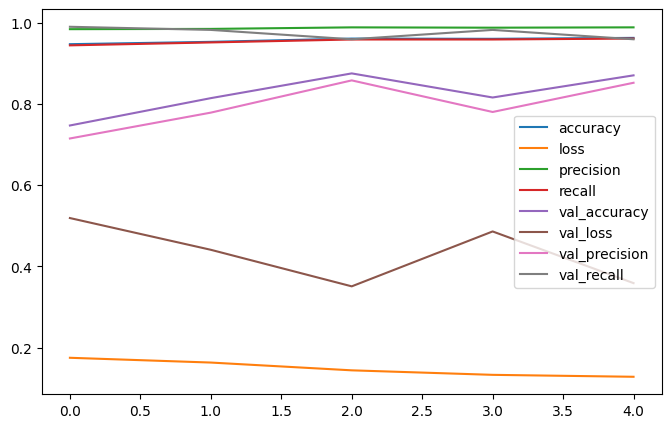

In [ ]:
pd.DataFrame(cnn_model_hist.history).plot(figsize=(8,5))

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 984ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 930ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 949ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 936ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 934ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 835ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step


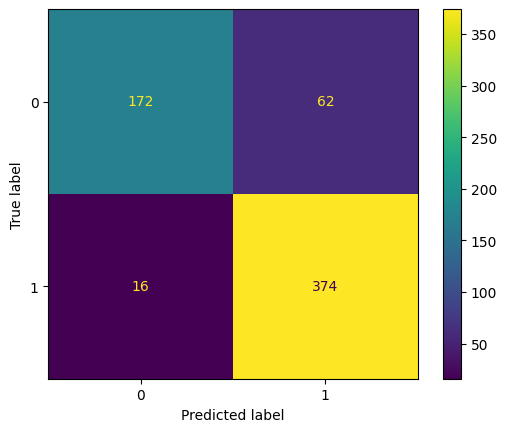

In [ ]:
predictions = cnn_model.predict(test_data)

y_pred = []
y_true = []

for image_batch, label_batch in test_data:
   y_true.append(label_batch)
   preds = cnn_model.predict(image_batch)
   y_pred.append(np.where(preds > 0.5, 1, 0))

true_labels = tf.concat([item for item in y_true], axis = 0)
predicted_labels = tf.concat([item for item in y_pred], axis = 0)

cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
print(classification_report(true_labels, predicted_labels))

              precision    recall  f1-score   support

           0       0.91      0.74      0.82       234
           1       0.86      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.85      0.86       624
weighted avg       0.88      0.88      0.87       624

